# Task 1: Linear Regression Model (California Housing Dataset)

**Name:** Neelima Killi

**Internship:** Maincrafts Technology

## Objective

Build and evaluate a Linear Regression model using the California Housing dataset.

In [45]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [46]:
# Load the California Housing dataset

housing = fetch_california_housing(as_frame=True)

df = housing.frame

print("Dataset loaded successfully!")

df.head()

Dataset loaded successfully!


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Exploratory Data Analysis (EDA)

In this section, we explore the dataset by checking its dimensions, columns, missing values, summary statistics, and the distribution of the target variable.

In [47]:
# Display dataset information

print("Shape of the dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
df.describe()

Shape of the dataset: (20640, 9)

Column Names:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Summary Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


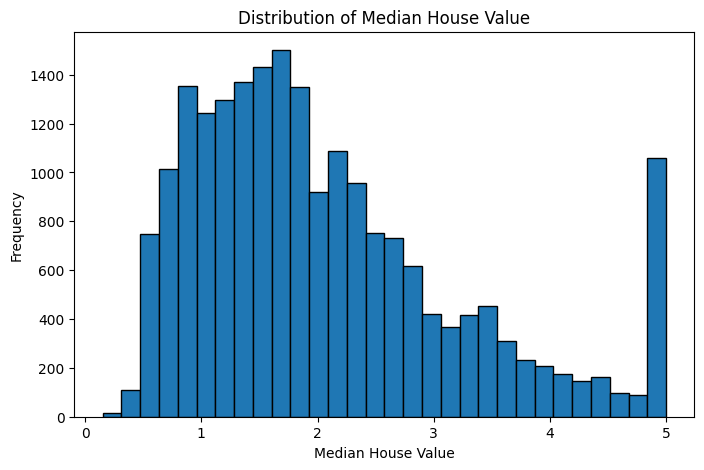

In [48]:
# Plot the distribution of house prices

plt.figure(figsize=(8,5))
plt.hist(df["MedHouseVal"], bins=30, edgecolor="black")

plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")

plt.show()

## Train-Test Split and Model Training

In this section, we split the dataset into training and testing sets, train a Linear Regression model, and fit it to the training data.

In [49]:
# Separate features and target

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

# Create model

model = LinearRegression()

# Train model

model.fit(X_train, y_train)

print("Model trained successfully!")

Training samples: (16512, 8)
Testing samples: (4128, 8)
Model trained successfully!


## Model Prediction

The trained model is used to predict house prices on the test dataset.

In [50]:
# Predict

y_pred = model.predict(X_test)

print("First 10 Predictions:")

print(y_pred[:10])

First 10 Predictions:
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


## Model Evaluation

Evaluate the performance of the Linear Regression model using MAE, MSE, RMSE, and R² Score.

In [51]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 0.5332001304956555
Mean Squared Error: 0.5558915986952442
Root Mean Squared Error: 0.7455813830127763
R² Score: 0.575787706032451


## Actual vs Predicted Values

Compare the actual house prices with the predicted values.

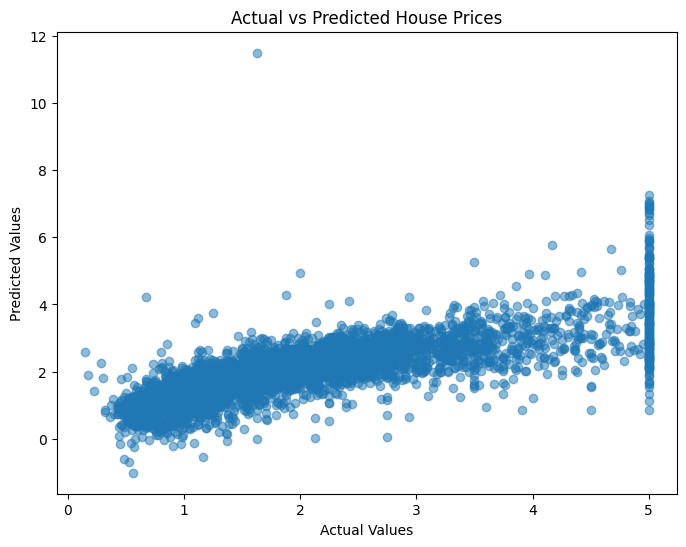

In [52]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Prices")

plt.show()
